In [814]:
import matplotlib.pyplot as plt
import random
import string
import collections
import math

In [815]:
N_sequence = 100
N1 = 4
list1 = [1 for i in range(N1)]
list0 = [0 for i in range(N_sequence - N1)]
original_sequence_1 = list0 + list1
random.shuffle(original_sequence_1)
original_sequence_1 = "".join(map(str, original_sequence_1))

In [816]:
def calculate_sequence_info(sequence):
    unique_chars = len(set(sequence))
    sequence_size = len(sequence)

    return {
        "unique_chars": unique_chars,
        "sequence_size": sequence_size
    }

In [817]:
def write_results(sequence, sequence_info):
    with open("results_sequence.txt", "a") as file:
        file.write("Послідовність: " + str(sequence) + "\nРозмір послідовності " + str(sequence_info["sequence_size"]) + " байт" + "\nРозмір алфавіту: " + str(sequence_info["unique_chars"]) + "\n")

In [818]:
sequence_info = calculate_sequence_info(original_sequence_1)
write_results(original_sequence_1, sequence_info)

In [819]:
N1 = 8
list1 = ["к", "о", "л", "і", "с", "н", "и", "к"]
list0 = list0 = [0 for i in range(N_sequence - N1)]
original_sequence_2 = list1 + list0
original_sequence_2 = "".join(map(str, original_sequence_2))

In [820]:
sequence_info = calculate_sequence_info(original_sequence_2)
write_results(original_sequence_2, sequence_info)

In [821]:
original_sequence_3 = original_sequence_2.split()
random.shuffle(original_sequence_3)
original_sequence_3 = "".join(map(str, original_sequence_3))

In [822]:
sequence_info = calculate_sequence_info(original_sequence_3)
write_results(original_sequence_3, sequence_info)

In [823]:
letters = ["к", "о", "л", "і", "с", "н", "и", "к", 5, 2, 6]
n_letters = len(letters)
n_repeats = N_sequence // n_letters
remainder = N_sequence % n_letters

list = letters * n_repeats
list += letters[:remainder]
original_sequence_4 = "".join(map(str, list))

In [824]:
sequence_info = calculate_sequence_info(original_sequence_4)
write_results(original_sequence_4, sequence_info)

In [825]:
list = ["к", "о", 5, 2, 6]
n_letters = len(list)
n_repeats = N_sequence // n_letters
remainder = N_sequence % n_letters

original_sequence_5 = list * n_repeats
random.shuffle(original_sequence_5)
original_sequence_5 = "".join(map(str, list))

In [826]:
sequence_info = calculate_sequence_info(original_sequence_5)
write_results(original_sequence_5, sequence_info)

In [827]:
letters = ["к", "о"]
digits = [5, 2, 6]
n_letters = int(0.7 * N_sequence)
n_digits = int(0.3 * N_sequence)
list_100 = []

for i in range(n_letters):
    list_100.append(random.choice(letters))
for i in range(n_digits):
    list_100.append(random.choice(digits))

random.shuffle(list_100)
original_sequence_6 = "".join(map(str, list_100))

In [828]:
sequence_info = calculate_sequence_info(original_sequence_6)
write_results(original_sequence_6, sequence_info)

In [829]:
elements = string.ascii_lowercase + string.digits
list_100 = [random.choice(elements) for _ in range(N_sequence)]
original_sequence_7 = "".join(map(str, list_100))

In [830]:
sequence_info = calculate_sequence_info(original_sequence_7)
write_results(original_sequence_7, sequence_info)

In [831]:
original_sequence_8 = [1 for i in range(N_sequence)]
original_sequence_8 = "".join(map(str, original_sequence_8))

In [832]:
sequence_info = calculate_sequence_info(original_sequence_8)
write_results(original_sequence_8, sequence_info)

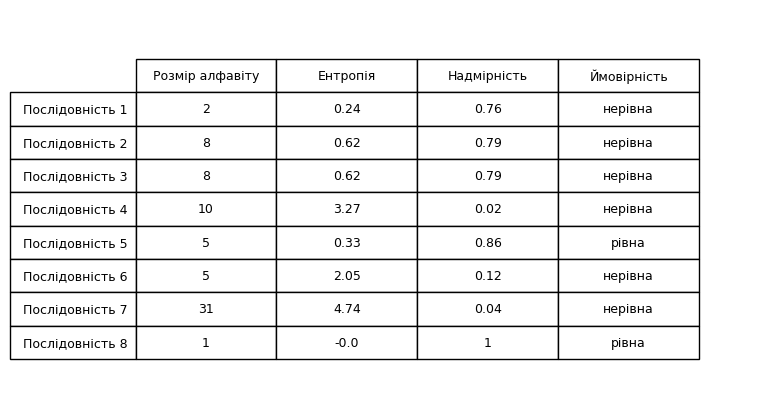

In [833]:
original_sequences = [original_sequence_1, original_sequence_2, original_sequence_3, original_sequence_4, original_sequence_5, original_sequence_6, original_sequence_7, original_sequence_8]

results = []
for sequence in original_sequences:
    counts = collections.Counter(sequence)
    probability = {symbol: count / N_sequence for symbol, count in counts.items()}
    mean_probability = sum(probability.values()) / len(probability)

    equal = all(abs(prob - mean_probability) < 0.05 * mean_probability for prob in probability.values())
    if equal:
        uniformity="рівна"
    else:
        uniformity = "нерівна"

    entropy = -sum(p * math.log2(p) for p in probability.values())

    sequence_alphabet_size = calculate_sequence_info(sequence)["unique_chars"]

    if sequence_alphabet_size > 1:
        source_excess = 1 - entropy / math.log2(sequence_alphabet_size)
    else:
        source_excess = 1

    probability_str = ", ".join([f"{symbol}={prob:.4f}" for symbol, prob in probability.items()])

    results.append ([sequence_alphabet_size, round((entropy),2), round((source_excess),2), uniformity])

    with open("sequence.txt", "a") as file:
        file.write("Послідовність: " + str(sequence) + "\nРозмір послідовності " + str(sequence_info["sequence_size"]) + " байт" + "\nРозмір алфавіту: " + str(sequence_info["unique_chars"]) + "\nЙмовірності появи символів: " + str(probability) + "\nСереднє арифметичне ймовірностей: " + str(mean_probability) + "\nЙмовірність розподілу символів:" + uniformity + "\nЕнтропія: " + str(entropy) + "\nНадмірність джерела: " + str(source_excess) + "\n")

fig, ax = plt.subplots(figsize=(14 / 1.54, 8 / 1.54))
headers = ["Розмір алфавіту", "Ентропія", "Надмірність", "Ймовірність"]
row = ["Послідовність 1", "Послідовність 2", "Послідовність 3", "Послідовність 4","Послідовність 5", "Послідовність 6", "Послідовність 7", "Послідовність 8"]
ax.axis("off")
table = ax.table(cellText=results, colLabels=headers, rowLabels=row, loc="center", cellLoc="center")
table.set_fontsize(14)
table.scale(0.8, 2)
plt.savefig("Характеристики сформованих послідовностей", dpi=600)
    
